In [38]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import sampling_sgd
from sampling_sgd import StochasticLinearRegressor
from mpl_toolkits.mplot3d import Axes3D

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
N = 1000000
theta = np.array([3,1,2])
imput_mean = np.array([3,-1])
input_sigma = np.array([2,2])
noise_sigma = np.sqrt(2.0)

In [40]:
X_train,y_train = sampling_sgd.generate(int(N*0.8),theta,imput_mean,input_sigma,noise_sigma)
X_test,y_test = sampling_sgd.generate(int(N*0.2),theta,imput_mean,input_sigma,noise_sigma)


def plot_train_data(X_train,y_train):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_train[:,0], X_train[:,1], y_train ,s=1)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    plt.show()
#plot_train_data(X_train,y_train)



In [47]:
SGD = StochasticLinearRegressor()

Thetas_epoch_history = SGD.fit(X_train,y_train,0.001)


Epoch: 0 for 1
Epoch: 1 for 1
Epoch: 2 for 1
Epoch: 3 for 1
Epoch: 4 for 1
Epoch: 5 for 1
Epoch: 6 for 1
Epoch: 7 for 1
Epoch: 8 for 1
Epoch: 9 for 1

Batch size: 1
 Epochs: 10 
 Theta: [2.96818434 1.03284694 1.99779834]

Epoch: 0 for 80
Epoch: 1 for 80
Epoch: 2 for 80
Epoch: 3 for 80
Epoch: 4 for 80
Epoch: 5 for 80
Epoch: 6 for 80
Epoch: 7 for 80
Epoch: 8 for 80
Epoch: 9 for 80
Epoch: 10 for 80
Epoch: 11 for 80
Epoch: 12 for 80
Epoch: 13 for 80
Epoch: 14 for 80
Epoch: 15 for 80
Epoch: 16 for 80
Epoch: 17 for 80
Epoch: 18 for 80
Epoch: 19 for 80
Epoch: 20 for 80
Epoch: 21 for 80
Epoch: 22 for 80
Epoch: 23 for 80
Epoch: 24 for 80
Epoch: 25 for 80
Epoch: 26 for 80
Epoch: 27 for 80
Epoch: 28 for 80
Epoch: 29 for 80
Epoch: 30 for 80
Epoch: 31 for 80
Epoch: 32 for 80
Epoch: 33 for 80
Epoch: 34 for 80
Epoch: 35 for 80
Epoch: 36 for 80
Epoch: 37 for 80
Epoch: 38 for 80
Epoch: 39 for 80
Epoch: 40 for 80
Epoch: 41 for 80
Epoch: 42 for 80
Epoch: 43 for 80
Epoch: 44 for 80
Epoch: 45 for 80
Epoch:

KeyboardInterrupt: 

In [42]:
Thetas_history = SGD.theta_itr_history
Thetas = SGD.learned_thetas
print(Thetas)


[[2.96622132 1.01084371 1.96001258]
 [3.00158446 0.99662716 2.008054  ]
 [3.00194943 0.99986663 2.00063523]
 [2.81885748 1.03968382 1.98744731]]


In [43]:
def mean_squared_error(y_true, y_pred):

    return np.mean((y_true - y_pred) ** 2)

# Compute predictions using closed-form solution


for i in range(0,4):

    theta = SGD.learned_thetas[i]
    batch_size = SGD.batch_sizes[i]

    print(theta)
    X_test__ = np.column_stack((np.ones(X_test.shape[0]), X_test))
    X_train__ = np.column_stack((np.ones(X_train.shape[0]), X_train))
    y_train_pred = X_train__ @ theta
    y_test_pred = X_test__ @ theta

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Print results
    print("----------------------------")

    print(f"For batch size :{batch_size}")
    print(f"Training MSE: {train_mse:.6f}")
    print(f"Test MSE: {test_mse:.6f}")

    print("----------------------------")



[2.96622132 1.01084371 1.96001258]
----------------------------
For batch size :1
Training MSE: 2.008011
Test MSE: 2.020079
----------------------------
[3.00158446 0.99662716 2.008054  ]
----------------------------
For batch size :80
Training MSE: 1.999924
Test MSE: 2.013244
----------------------------
[3.00194943 0.99986663 2.00063523]
----------------------------
For batch size :8000
Training MSE: 1.999394
Test MSE: 2.012493
----------------------------
[2.81885748 1.03968382 1.98744731]
----------------------------
For batch size :800000
Training MSE: 2.008991
Test MSE: 2.022310
----------------------------


In [44]:
def closed_form_solution(X, y):
    
    # theta = (X^T * X)^(-1) * X^T * y
    X = np.c_[np.ones(X.shape[0]), X] 
    
    theta = np.linalg.inv(X.T @ X) @ X.T @ y
    return theta

Theta = closed_form_solution(X_train,y_train)

print("Theta from closed form solution: ", Theta)

X_test__ = np.column_stack((np.ones(X_test.shape[0]), X_test))
X_train__ = np.column_stack((np.ones(X_train.shape[0]), X_train))

print("MSE for closed form solution: ", mean_squared_error(y_train, X_train__ @ Theta))
print("MSE for closed form solution: ", mean_squared_error(y_test, X_test__ @ Theta))




Theta from closed form solution:  [3.00189453 0.99966976 2.00073748]
MSE for closed form solution:  1.9993929386586349
MSE for closed form solution:  2.0124952534356555


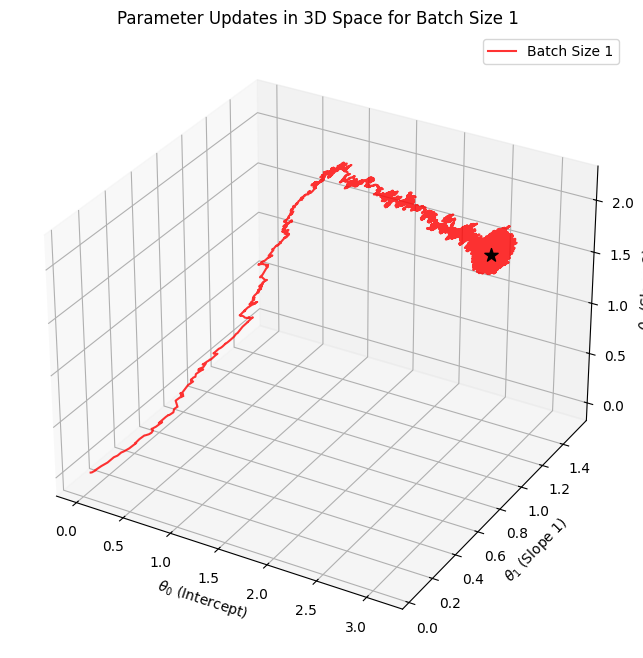

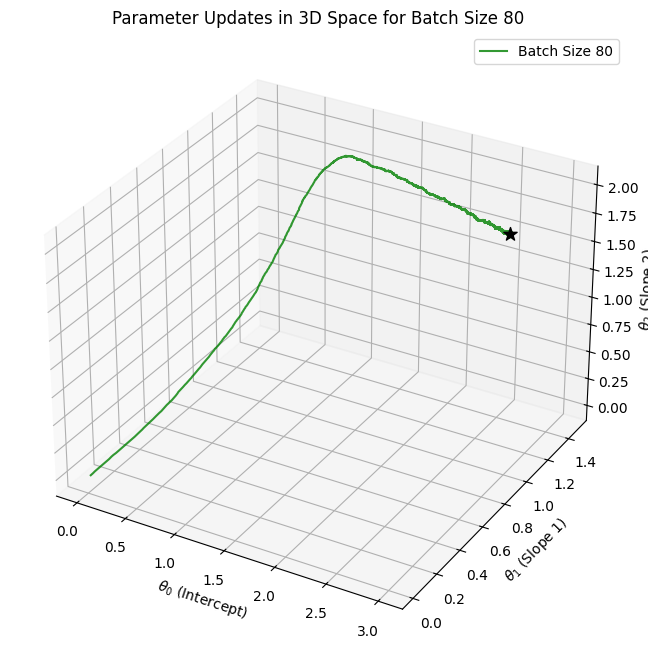

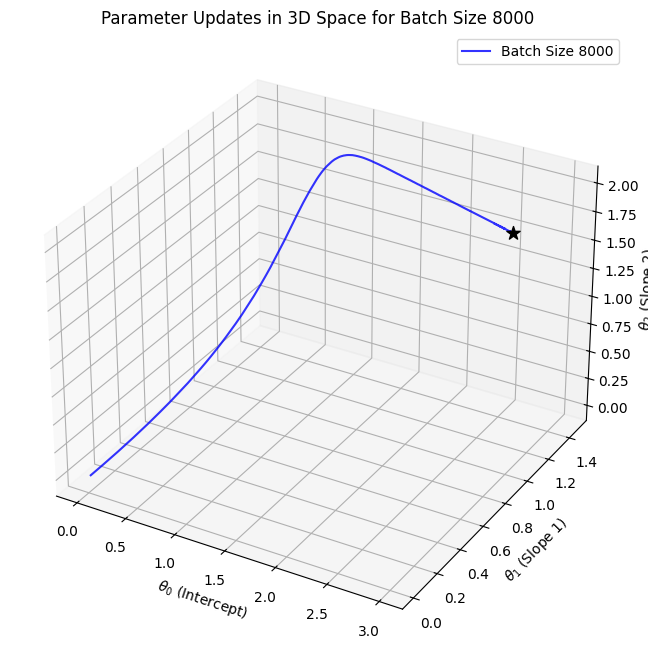

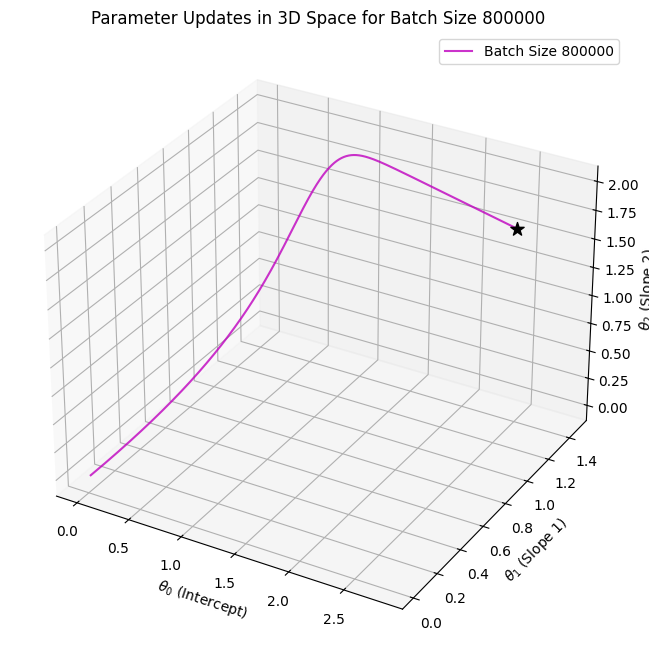

[1, 80, 8000, 800000]
(8000000, 3) (1000000, 3) (100000, 3) (10000, 3)


In [45]:
import matplotlib.pyplot as plt
import numpy as np

def plot_theta_updates(theta_histories, batch_sizes):
    """
    Plot the movement of θ (parameters) over iterations for different batch sizes.

    Parameters
    ----------
    theta_histories : list of numpy arrays
        List of numpy arrays, where each array contains θ values at each iteration.
        
    batch_sizes : list
        List of batch sizes corresponding to each θ history.
    """

    colors = ['r', 'g', 'b', 'm']
    
    for i, batch_size in enumerate(batch_sizes):
        theta_history = np.array(theta_histories[i])

        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')

        ax.plot(theta_history[:, 0], theta_history[:, 1], theta_history[:, 2], 
                label=f'Batch Size {batch_size}', color=colors[i], alpha=0.8)

        ax.set_xlabel(r'$\theta_0$ (Intercept)')
        ax.set_ylabel(r'$\theta_1$ (Slope 1)')
        ax.set_zlabel(r'$\theta_2$ (Slope 2)')

        # Plot the final point in Theta 
        ax.scatter(theta_history[-1, 0], theta_history[-1, 1], theta_history[-1, 2], 
                   color="black", s=100, marker='*')
    
        ax.set_title(f'Parameter Updates in 3D Space for Batch Size {batch_size}')
        ax.legend()
        plt.show()


plot_theta_updates(Thetas_history, SGD.batch_sizes)
print(SGD.batch_sizes)
print(Thetas_history[0].shape, Thetas_history[1].shape, Thetas_history[2].shape, Thetas_history[3].shape)

In [46]:
print(SGD.theta_itr_history[0].shape, SGD.theta_itr_history[1].shape, SGD.theta_itr_history[2].shape, SGD.theta_itr_history[3].shape)

(8000000, 3) (1000000, 3) (100000, 3) (10000, 3)
